# Car Price Model Evaluation...

                              name  year  selling_price  km_driven    fuel  \
0           Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1     Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2         Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3        Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4           Maruti Swift VXI BSIII  2007         130000     120000  Petrol   
...                            ...   ...            ...        ...     ...   
8123             Hyundai i20 Magna  2013         320000     110000  Petrol   
8124         Hyundai Verna CRDi SX  2007         135000     119000  Diesel   
8125        Maruti Swift Dzire ZDi  2009         382000     120000  Diesel   
8126               Tata Indigo CR4  2013         290000      25000  Diesel   
8127               Tata Indigo CR4  2013         290000      25000  Diesel   

     seller_type transmission                 owner  mileage(km

C:\Users\Vishnu Kant\AppData\Local\Temp\ipykernel_16556\4194053595.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


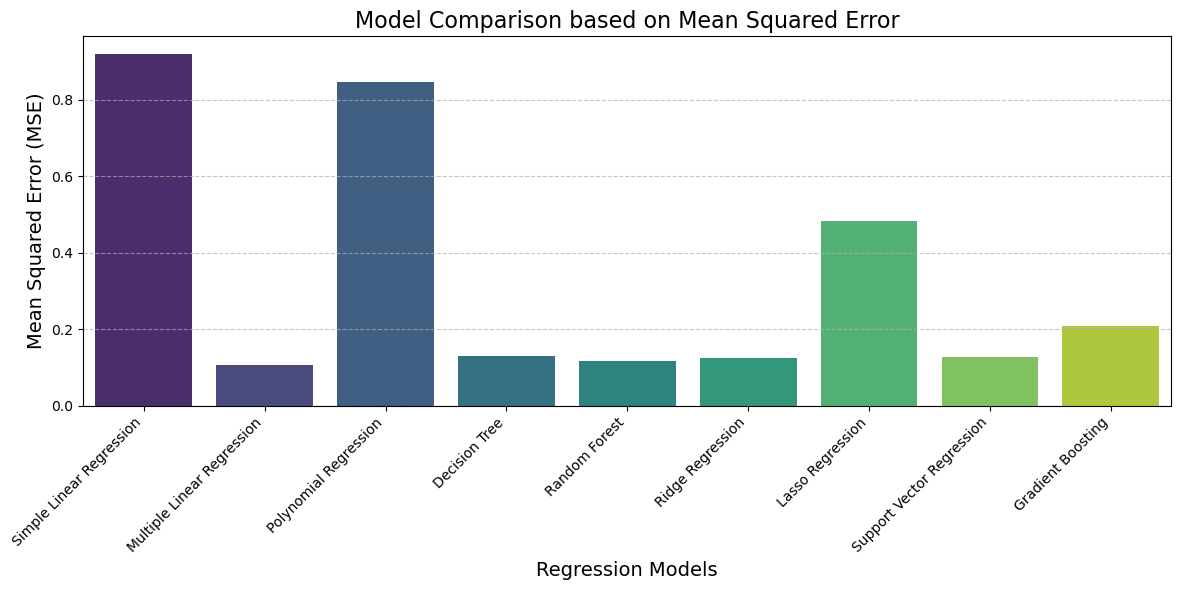


Model Performance (Mean Squared Error):

Simple Linear Regression: 0.92
Multiple Linear Regression: 0.11
Polynomial Regression: 0.85
Decision Tree: 0.13
Random Forest: 0.12
Ridge Regression: 0.12
Lasso Regression: 0.48
Support Vector Regression: 0.13
Gradient Boosting: 0.21


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load dataset
data = pd.read_csv('car model/cardekho.csv')

# Show first few rows
print(data)

# Drop missing values
data.dropna(inplace=True)

# Feature and Target
X = data.drop('seats', axis=1)
y = data['seats']

# Handle categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models and Results Dictionaries
models = {}
results = {}

# Simple Linear Regression (Only 'km_driven')
lr_simple = LinearRegression()
lr_simple.fit(X_train[['km_driven']], y_train)

y_pred_simple = lr_simple.predict(X_test[['km_driven']])
results['Simple Linear Regression'] = mean_squared_error(y_test, y_pred_simple)
models['Simple Linear Regression'] = lr_simple

# Multiple Linear Regression
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

y_pred_multi = lr_multi.predict(X_test)
results['Multiple Linear Regression'] = mean_squared_error(y_test, y_pred_multi)
models['Multiple Linear Regression'] = lr_multi

# Polynomial Regression (only on 'km_driven') 
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[['km_driven']])
X_test_poly = poly.transform(X_test[['km_driven']])

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)
results['Polynomial Regression'] = mean_squared_error(y_test, y_pred_poly)
models['Polynomial Regression'] = poly_reg

# Decision Tree Regressor -
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
results['Decision Tree'] = mean_squared_error(y_test, y_pred_tree)
models['Decision Tree'] = tree

# Random Forest Regressor 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
results['Random Forest'] = mean_squared_error(y_test, y_pred_rf)
models['Random Forest'] = rf

# Ridge Regression 
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
results['Ridge Regression'] = mean_squared_error(y_test, y_pred_ridge)
models['Ridge Regression'] = ridge

# Lasso Regression 
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)
results['Lasso Regression'] = mean_squared_error(y_test, y_pred_lasso)
models['Lasso Regression'] = lasso

# Support Vector Regression (SVR)
svr = SVR(kernel='linear')
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
results['Support Vector Regression'] = mean_squared_error(y_test, y_pred_svr)
models['Support Vector Regression'] = svr

# Gradient Boosting Regressor 
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
results['Gradient Boosting'] = mean_squared_error(y_test, y_pred_gb)
models['Gradient Boosting'] = gb


# Plotting the Model Performance
plt.figure(figsize=(12, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Comparison based on Mean Squared Error', fontsize=16)
plt.xlabel('Regression Models', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nModel Performance (Mean Squared Error):\n")
for model_name, mse in results.items():
    print(f"{model_name}: {mse:.2f}")
